# Classical EEG feature extraction

## tl;dr

- The synthetic 10 Hz and 20 Hz channels recover their expected alpha/beta bands, dominant frequencies, and mean-square powers.
- OAS covariance, correlation, and log-covariance are finite and symmetric.
- The canonical `Data_Pattern/patt` sample `(1, 1, 1)` produces the documented modular feature blocks for both a full 15 s imagery epoch and configurable complete windows.
- This notebook validates feature computation only. It does not define a prediction target, split, or ML performance claim.

## Context & Methods

The notebook exercises the public API in `features/`. The canonical half-open crop is `[0.5, 15.5)` seconds and is applied before resampling from 1000 Hz to 125 Hz.

### Key assumptions

- `Data_Pattern/patt` is used as the real visual-imagery demonstration source.
- A window remains a child of its source block. Window rows must not later be split independently across ML folds.
- No scaler, PCA, selector, threshold, or model is fitted here.
- Sources: local FIF and `labels.json`, repository feature code, and the project EEG semantic layer.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-classical-features")

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from features import extract_classical_feature_blocks, load_feature_config
from utils.datasets import NumpyDataset

TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "blue": "#A3BEFA",
    "blue_dark": "#2E4780",
    "gold": "#FFE15B",
    "gold_dark": "#736422",
}
plt.rcParams.update({
    "figure.facecolor": TOKENS["surface"],
    "axes.facecolor": TOKENS["panel"],
    "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"],
    "axes.titlecolor": TOKENS["ink"],
    "xtick.color": TOKENS["muted"],
    "ytick.color": TOKENS["muted"],
    "grid.color": TOKENS["grid"],
    "font.family": "DejaVu Sans",
})

def block_map(blocks):
    return {block.name: block for block in blocks}

def add_header(ax, title, subtitle):
    ax.set_title(title, loc="left", fontsize=12, fontweight="semibold", pad=24)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=8.5, color=TOKENS["muted"])
    ax.spines[["top", "right"]].set_visible(False)

DEFAULT_CONFIG = load_feature_config(overrides={"feature_groups": ["time", "spectral", "spatial"]})
DEFAULT_CONFIG

FeatureExtractionConfig(analysis_sfreq=125.0, crop_start_seconds=0.5, crop_end_seconds=15.5, window_seconds=None, window_stride_seconds=None, dtype='float32', feature_groups=('time', 'spectral', 'spatial'), frequency_bands=(FrequencyBand(name='delta', f_min=2.0, f_max=4.0), FrequencyBand(name='theta', f_min=4.0, f_max=8.0), FrequencyBand(name='alpha', f_min=8.0, f_max=13.0), FrequencyBand(name='beta', f_min=13.0, f_max=30.0), FrequencyBand(name='low_gamma', f_min=30.0, f_max=40.0)), histogram_mode='probability', local_pattern_neighbors=8, transform_eog=False, filter_hz=None, notch_hz=None, reference=None, normalization='none')

## Data

### 1. Build deterministic synthetic channels

The source-rate block follows the real 16.001 s `exec` geometry. Channel `alpha_10hz` has amplitude 2, so its expected mean-square power is 2. Channel `beta_20hz` has amplitude 1, so its expected mean-square power is 0.5.

In [2]:
source_sfreq = 1_000.0
source_times = np.arange(16_001, dtype=np.float64) / source_sfreq
rng = np.random.default_rng(2026)
synthetic_eeg = np.stack([
    2.0 * np.sin(2.0 * np.pi * 10.0 * source_times),
    np.sin(2.0 * np.pi * 20.0 * source_times),
    0.75 * np.sin(2.0 * np.pi * 10.0 * source_times) + 0.05 * rng.normal(size=source_times.size),
]).astype(np.float32)

synthetic_blocks, synthetic_bounds = extract_classical_feature_blocks(
    synthetic_eeg,
    source_sfreq=source_sfreq,
    config=DEFAULT_CONFIG,
)
synthetic = block_map(synthetic_blocks)
synthetic_summary = pd.DataFrame(
    synthetic["spectral"].values[0],
    index=["alpha_10hz", "beta_20hz", "correlated_alpha"],
    columns=synthetic["spectral"].feature_names,
)
synthetic_summary[[
    "absolute_band_power_alpha",
    "absolute_band_power_beta",
    "total_power",
    "dominant_frequency",
    "spectral_centroid",
    "spectral_entropy",
]]

,absolute_band_power_alpha,absolute_band_power_beta,total_power,dominant_frequency,spectral_centroid,spectral_entropy
alpha_10hz,2.001444e+00,2.111349e-17,2.001444,10.0,10.000000,5.032012e-16
beta_20hz,5.461814e-18,5.010907e-01,0.501091,20.0,20.000000,7.076724e-16
correlated_alpha,2.821407e-01,8.732535e-05,0.282315,10.0,10.007594,2.233348e-03


## Results

### 2. Verify spectral localization and scaling

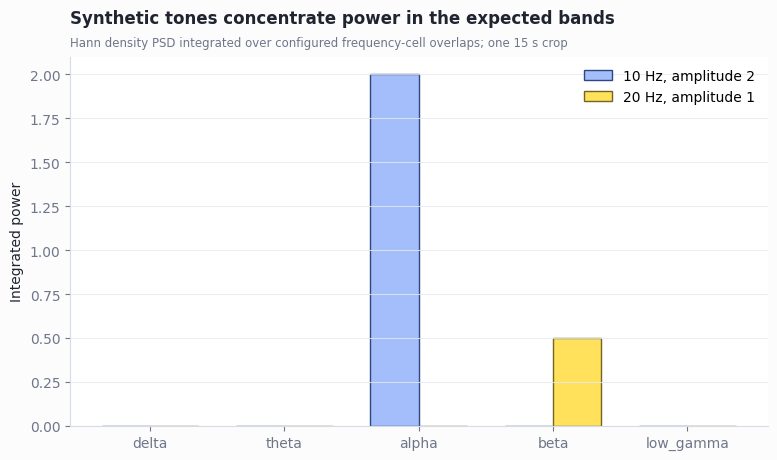

In [3]:
alpha_power = synthetic_summary.loc["alpha_10hz", "absolute_band_power_alpha"]
assert np.isclose(alpha_power, 2.0, rtol=0.02)
assert np.isclose(synthetic_summary.loc["beta_20hz", "absolute_band_power_beta"], 0.5, rtol=0.02)
assert synthetic_summary.loc["alpha_10hz", "dominant_frequency"] == 10.0
assert synthetic_summary.loc["beta_20hz", "dominant_frequency"] == 20.0

band_columns = [f"absolute_band_power_{band.name}" for band in DEFAULT_CONFIG.frequency_bands]
band_labels = [band.name for band in DEFAULT_CONFIG.frequency_bands]
x = np.arange(len(band_labels))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(
    x - width / 2,
    synthetic_summary.loc["alpha_10hz", band_columns],
    width,
    label="10 Hz, amplitude 2",
    color=TOKENS["blue"],
    edgecolor=TOKENS["blue_dark"],
)
ax.bar(
    x + width / 2,
    synthetic_summary.loc["beta_20hz", band_columns],
    width,
    label="20 Hz, amplitude 1",
    color=TOKENS["gold"],
    edgecolor=TOKENS["gold_dark"],
)
ax.set_xticks(x, band_labels)
ax.set_ylabel("Integrated power")
ax.grid(axis="y", alpha=0.8)
ax.legend(frameon=False, loc="upper right")
add_header(ax, "Synthetic tones concentrate power in the expected bands", "Hann density PSD integrated over configured frequency-cell overlaps; one 15 s crop")
plt.show()

### 3. Inspect spatial matrices

The third channel shares a 10 Hz component with the first channel, so their correlation should be strongly positive.

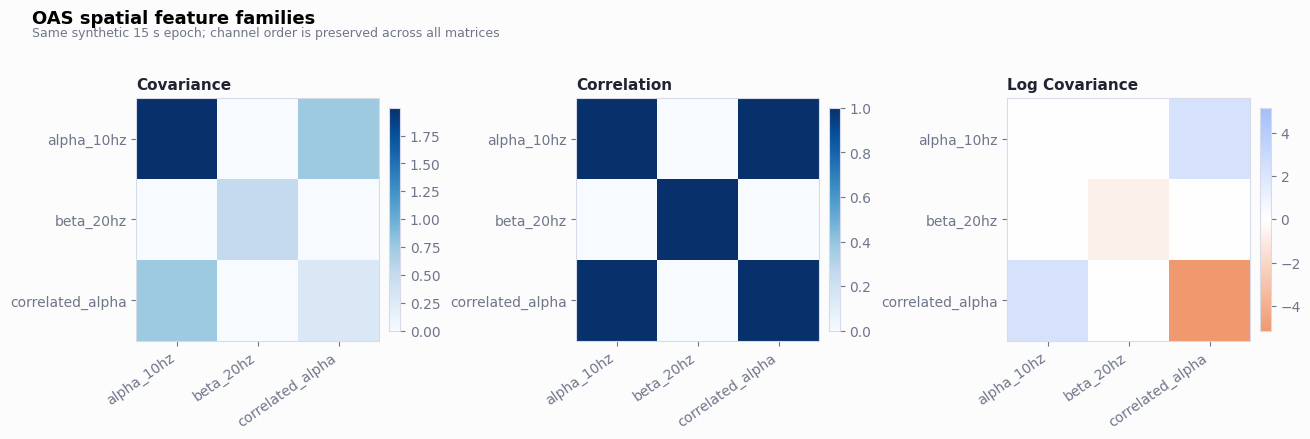

In [4]:
channel_labels = ["alpha_10hz", "beta_20hz", "correlated_alpha"]
matrix_names = ["covariance", "correlation", "log_covariance"]
signed_cmap = LinearSegmentedColormap.from_list("signed", ["#F0986E", "#FFFFFF", "#A3BEFA"])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), constrained_layout=True)
for ax, name in zip(axes, matrix_names, strict=True):
    matrix = synthetic[name].values[0]
    if name == "log_covariance":
        limit = np.max(np.abs(matrix))
        image = ax.imshow(matrix, cmap=signed_cmap, norm=TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit), aspect="equal")
    else:
        image = ax.imshow(matrix, cmap="Blues", aspect="equal")
    ax.set_xticks(range(3), channel_labels, rotation=35, ha="right")
    ax.set_yticks(range(3), channel_labels)
    ax.set_title(name.replace("_", " ").title(), loc="left", fontsize=11, fontweight="semibold")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    assert np.isfinite(matrix).all()
    assert np.allclose(matrix, matrix.T)
assert synthetic["correlation"].values[0, 0, 2] > 0.9
fig.suptitle("OAS spatial feature families", x=0.02, ha="left", fontsize=13, fontweight="semibold")
fig.text(0.02, 0.93, "Same synthetic 15 s epoch; channel order is preserved across all matrices", color=TOKENS["muted"], fontsize=9)
plt.show()

### 4. Load one canonical imagery block

This is a bounded demonstration of the source key `(subject=1, trial=1, block=1)` from `Data_Pattern` using `dataset_step_type="patt"`.

In [5]:
imagery_dataset = NumpyDataset(
    PROJECT_ROOT / "data" / "Data_Pattern",
    dataset_step_type="patt",
    cache_policy="disk",
)
imagery_sample = imagery_dataset[1, 1, 1]
full_blocks, full_bounds = extract_classical_feature_blocks(
    imagery_sample.eeg,
    source_sfreq=imagery_sample.sfreq,
    config=DEFAULT_CONFIG,
)
window_config = load_feature_config(overrides={
    "feature_groups": ["time", "spectral", "spatial"],
    "window_seconds": 5.0,
    "window_stride_seconds": 2.0,
})
window_blocks, window_bounds = extract_classical_feature_blocks(
    imagery_sample.eeg,
    source_sfreq=imagery_sample.sfreq,
    config=window_config,
)
full = block_map(full_blocks)
windowed = block_map(window_blocks)

real_summary = pd.DataFrame({
    "source_key": ["(1, 1, 1)"],
    "recording_family": ["Data_Pattern/patt"],
    "source_shape": [imagery_sample.eeg.shape],
    "full_bounds_seconds": [full_bounds.tolist()],
    "window_count": [len(window_bounds)],
    "first_window_seconds": [window_bounds[0].tolist()],
    "last_window_seconds": [window_bounds[-1].tolist()],
})
real_summary

,source_key,recording_family,source_shape,full_bounds_seconds,window_count,first_window_seconds,last_window_seconds
0,"(1, 1, 1)",Data_Pattern/patt,"(63, 26001)","[[0.5, 15.5]]",6,"[0.5, 5.5]","[10.5, 15.5]"


### 5. Compare full-epoch and windowed real features

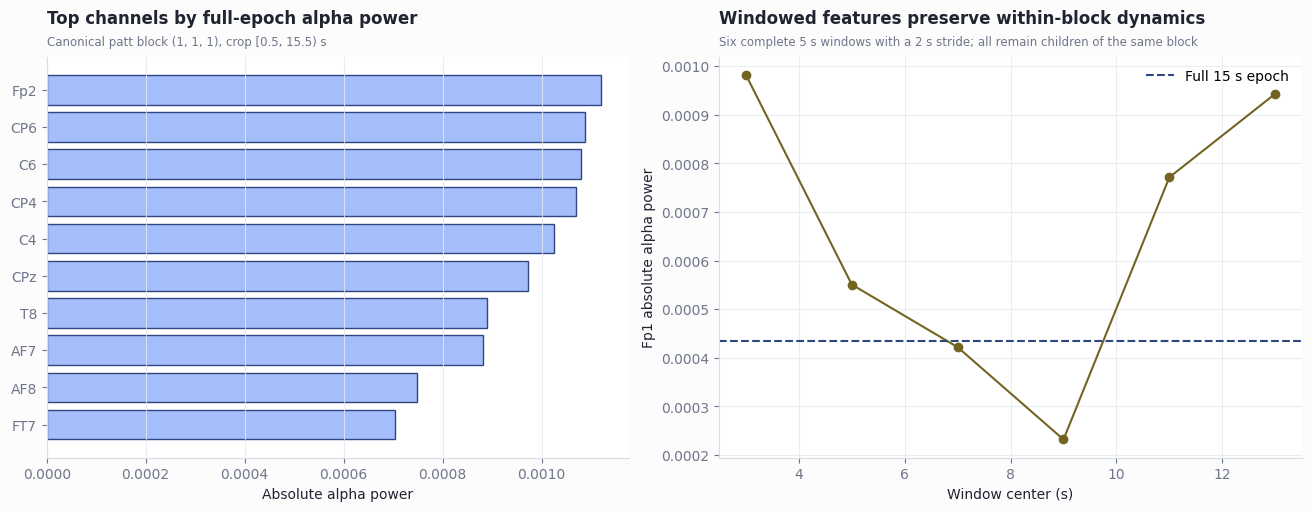

CLASSICAL_FEATURES_VERIFIED


In [6]:
alpha_name = "absolute_band_power_alpha"
alpha_index = windowed["spectral"].feature_names.index(alpha_name)
full_alpha = full["spectral"].values[0, :, alpha_index]
window_alpha = windowed["spectral"].values[:, :, alpha_index]
top_channels = np.argsort(full_alpha)[-10:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].barh(
    np.asarray(imagery_sample.eeg_channels)[top_channels][::-1],
    full_alpha[top_channels][::-1],
    color=TOKENS["blue"],
    edgecolor=TOKENS["blue_dark"],
)
axes[0].set_xlabel("Absolute alpha power")
axes[0].grid(axis="x", alpha=0.8)
add_header(axes[0], "Top channels by full-epoch alpha power", "Canonical patt block (1, 1, 1), crop [0.5, 15.5) s")

fp1_index = imagery_sample.eeg_channels.index("Fp1")
window_centers = window_bounds.mean(axis=1)
axes[1].plot(window_centers, window_alpha[:, fp1_index], marker="o", color=TOKENS["gold_dark"])
axes[1].axhline(full_alpha[fp1_index], color=TOKENS["blue_dark"], linestyle="--", label="Full 15 s epoch")
axes[1].set_xlabel("Window center (s)")
axes[1].set_ylabel("Fp1 absolute alpha power")
axes[1].grid(alpha=0.8)
axes[1].legend(frameon=False)
add_header(axes[1], "Windowed features preserve within-block dynamics", "Six complete 5 s windows with a 2 s stride; all remain children of the same block")
plt.show()

for block in (*full_blocks, *window_blocks):
    assert np.isfinite(block.values).all()
assert full["time"].values.shape == (1, 63, 13)
assert full["spectral"].values.shape == (1, 63, 14)
assert windowed["time"].values.shape == (6, 63, 13)
assert windowed["spectral"].values.shape == (6, 63, 14)
assert all(windowed[name].values.shape == (6, 63, 63) for name in matrix_names)
print("CLASSICAL_FEATURES_VERIFIED")

## Takeaways

- Synthetic amplitudes and frequencies are recovered with the expected power scaling and band assignment.
- Spatial outputs preserve channel order and remain finite and symmetric.
- The real imagery example produces one full-epoch feature set or six configurable complete windows without changing the parent block identity.
- These outputs are ready for later dataset/cache integration. Any scaler, PCA, selector, or model must be fitted inside training folds only.